Referencia: https://www.kaggle.com/datasets/datatattle/covid-19-nlp-text-classification?select=Corona_NLP_test.csv

In [40]:
#Librerías para análisis de texto y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import re

# Librerías para la limpieza y preprocesamiento de texto
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Librerías para hacer vectorización
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Librerías para los modelos de ML / DL
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import time

# Numpy
import numpy as np

# Liberías para la evaluación de resultados
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Definición del enunciado

Clasificación Automatizada de Sentimientos y Análisis de la Percepción Ciudadana en Redes Sociales durante la Pandemia de COVID-19: Un Enfoque Comparativo entre Machine Learning Clásico y Modelos de Lenguaje Basados en Transformers

# Descripción

El objetivo de este proyecto es desarrollar un sistema de procesamiento de lenguaje natural (NLP) capaz de clasificar automáticamente el sentimiento expresado en tweets relacionados con la pandemia de COVID-19. Utilizando un conjunto de datos recolectado y etiquetado manualmente, se busca comparar la eficacia de modelos estadísticos tradicionales (como Naïve Bayes o SVM con Scikit-learn) frente a arquitecturas de aprendizaje profundo de última generación (como BERT o RoBERTa mediante la librería Transformers).

El proyecto abordará el ciclo completo de ciencia de datos: desde la limpieza y normalización de texto (tokenización, remoción de ruido y lematización con spaCy y NLTK), hasta el análisis exploratorio de datos (EDA) para identificar tendencias geográficas y temporales, culminando en la implementación de un modelo de clasificación multiclase de alta precisión.

# Apertura de los archivos a usar

In [22]:
df_train = pd.read_csv('Corona_NLP_train.csv', encoding='latin-1')
df_test = pd.read_csv('Corona_NLP_test.csv', encoding='latin-1')

En paso, ese lee y abre los archivos que contienen miles de comentarios de Twitter relacionados con el COVID-19.

# EDA de la data

Dimensiones del dataset: (41157, 6)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6748\3876221343.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Sentiment', order=df_train['Sentiment'].value_counts().index, palette='viridis')


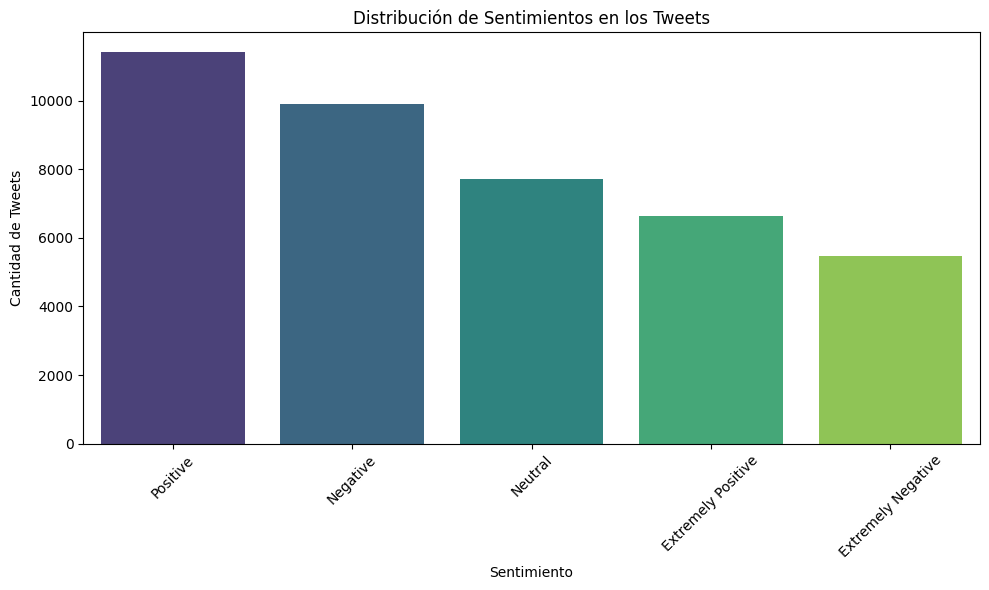

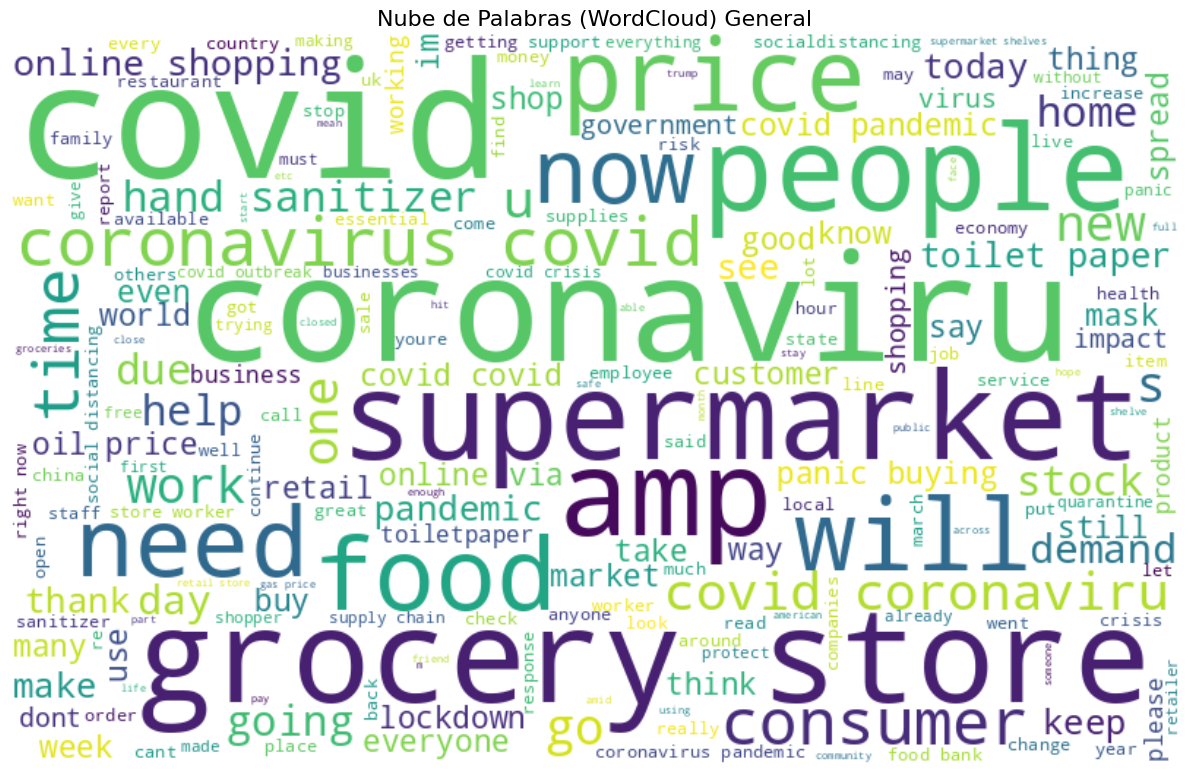

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6748\3876221343.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frecuencia', y='Palabra', data=words_df, palette='magma')


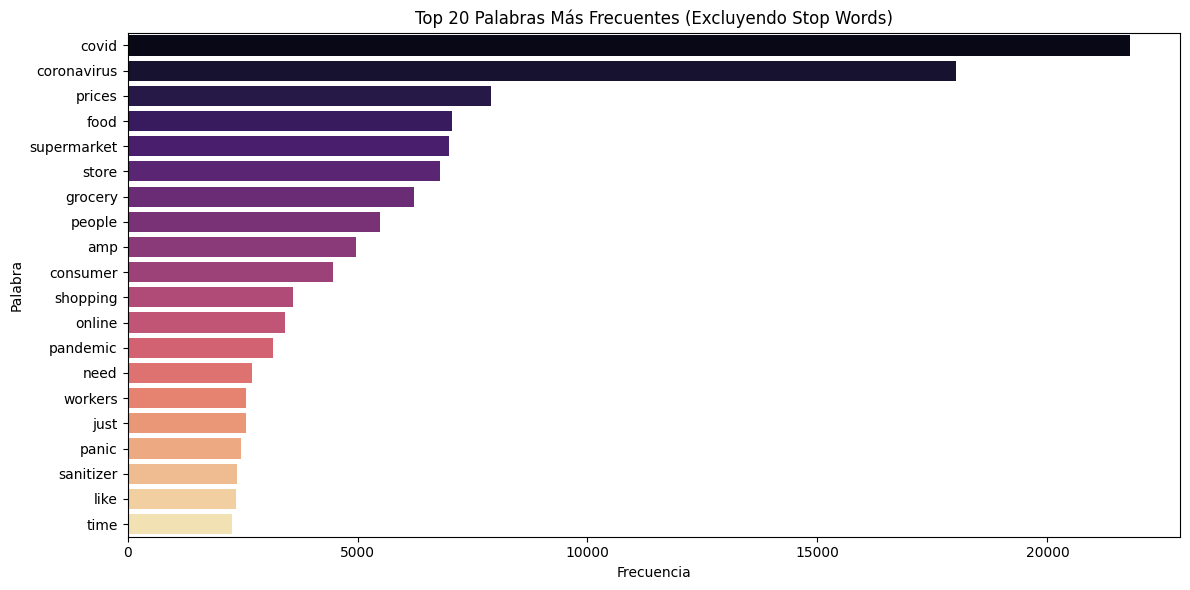

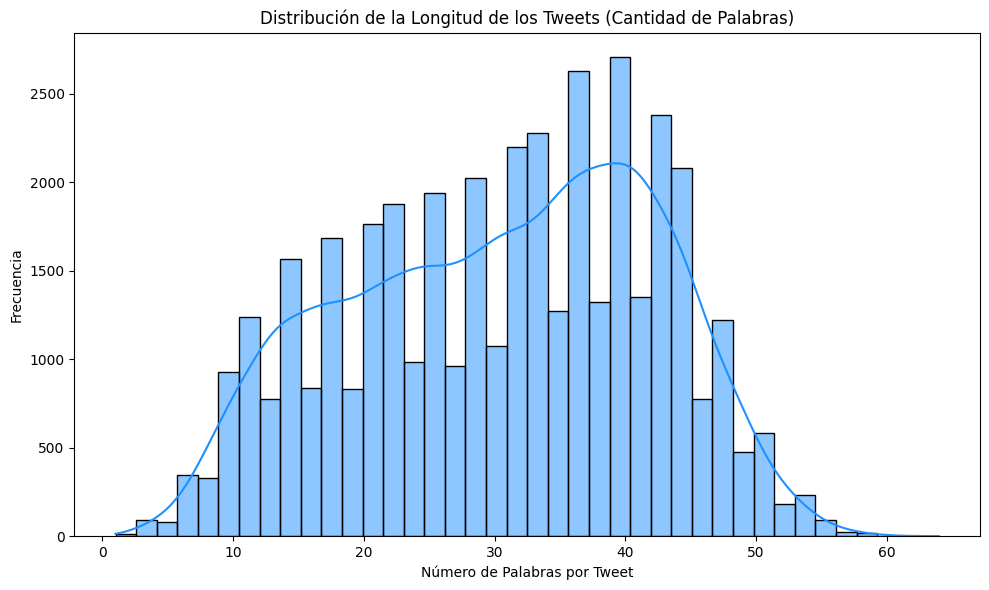

In [23]:
print("Dimensiones del dataset:", df_train.shape)

# ---------------------------------------------------------
# 2. DISTRIBUCIÓN DE SENTIMIENTOS
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Sentiment', order=df_train['Sentiment'].value_counts().index, palette='viridis')
plt.title('Distribución de Sentimientos en los Tweets')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. LIMPIEZA BÁSICA PARA EL EDA
# ---------------------------------------------------------
# Esta función hace una limpieza rápida solo para visualizar de qué hablan los tweets.
# Más adelante, para el modelo, usaremos spaCy/NLTK.
def clean_text_eda(text):
    text = str(text).lower()
    # Quitar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) 
    # Quitar menciones (@) y el símbolo de hashtag (dejando el texto)
    text = re.sub(r'\@\w+|\#', '', text) 
    # Quitar puntuación y números (dejar solo letras)
    text = re.sub(r'[^a-zA-Z\s]', '', text) 
    return text

# Aplicar la limpieza creando una nueva columna
df_train['clean_tweet_eda'] = df_train['OriginalTweet'].apply(clean_text_eda)

# ---------------------------------------------------------
# 4. NUBE DE PALABRAS (WORDCLOUD)
# ---------------------------------------------------------
all_words = ' '.join([text for text in df_train['clean_tweet_eda']])
wordcloud = WordCloud(width=800, height=500, random_state=42, 
                      max_font_size=110, background_color='white').generate(all_words)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('Nube de Palabras (WordCloud) General', fontsize=16)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. BAG OF WORDS (TOP 20 PALABRAS MÁS FRECUENTES)
# ---------------------------------------------------------
# Excluimos 'stop_words' en inglés nativas de scikit-learn
vectorizer = CountVectorizer(stop_words='english', max_features=20)
bow = vectorizer.fit_transform(df['clean_tweet_eda'])

# Sumar las frecuencias de cada palabra
sum_words = bow.sum(axis=0) 
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

# Crear un DataFrame para graficar fácilmente
words_df = pd.DataFrame(words_freq, columns=['Palabra', 'Frecuencia'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Frecuencia', y='Palabra', data=words_df, palette='magma')
plt.title('Top 20 Palabras Más Frecuentes (Excluyendo Stop Words)')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. DISTRIBUCIÓN DE LA LONGITUD DE LOS TWEETS
# ---------------------------------------------------------
# Contar cuántas palabras hay en cada tweet original
df_train['tweet_length'] = df_train['OriginalTweet'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_train['tweet_length'], bins=40, kde=True, color='dodgerblue')
plt.title('Distribución de la Longitud de los Tweets (Cantidad de Palabras)')
plt.xlabel('Número de Palabras por Tweet')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

En este bloque de código se realiza un Análisis Exploratorio de Datos (EDA) que comienza con la verificación de las dimensiones del dataset y el análisis visual del desbalance de clases mediante un gráfico de frecuencias para la variable objetivo. Posteriormente, se implementa una etapa de preprocesamiento ligero utilizando expresiones regulares para normalizar el texto (eliminando URLs, menciones y caracteres especiales), lo que permite generar una nube de palabras y un gráfico de "Bolsa de Palabras" (Bag of Words) para identificar los términos más dominantes y frecuentes dentro de la conversación. Finalmente, el código calcula y grafica la distribución de la longitud de los tweets para comprender la densidad de la información y establecer parámetros de entrada adecuados para los modelos de aprendizaje automático.

# Limpieza de la data

Limpieza de la data de entrenamiento

In [24]:
# Descargar recursos de NLT
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


# 1. Configurar Stopwords (Nativas + Personalizadas basadas en tu EDA)
stop_words = set(stopwords.words('english'))
custom_stopwords = {'covid', 'coronavirus', 'covid19', '19', 'amp', 'https', 'co'}
stop_words = stop_words.union(custom_stopwords)

# Inicializar el lematizador
lemmatizer = WordNetLemmatizer()

# 2. Función de Limpieza Profunda
def deep_clean_text(text):
    text = str(text).lower()
    
    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) 
    # Eliminar menciones de usuarios (ej. @usuario)
    text = re.sub(r'\@\w+', '', text) 
    # Eliminar el símbolo '#' pero conservar la palabra del hashtag
    text = re.sub(r'\#', '', text) 
    # Eliminar todo lo que no sea letra (números, puntuación, caracteres especiales)
    text = re.sub(r'[^a-z\s]', '', text) 
    
    # Tokenizar (separar por espacios)
    tokens = text.split()
    
    # Filtrar stopwords, aplicar longitud (entre 3 y 15 letras) y lematizar
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens 
        if word not in stop_words and 3 <= len(word) <= 15
    ]
    
    return " ".join(cleaned_tokens)

# 3. Aplicar la función al dataset
df_train['clean_tweet'] = df_train['OriginalTweet'].apply(deep_clean_text)

# 4. Filtrar filas que hayan quedado vacías después de la limpieza
df_train = df_train[df_train['clean_tweet'].str.strip() != '']

# 5. Guardar en formato Parquet
# Seleccionamos solo las columnas necesarias para optimizar espacio
df_final = df_train[['OriginalTweet', 'clean_tweet', 'Sentiment']]

# Guardar usando el motor de pyarrow (muy eficiente para compresión columnar)
df_final.to_parquet('Corona_NLP_train_cleaned.parquet', engine='pyarrow')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


En este pedazo de código se ejecuta el pipeline de preprocesamiento técnico y limpieza profunda de los datos, empezando con la descarga de recursos léxicos de NLTK y la configuración de una lista de palabras irrelevantes (stopwords) personalizada según los hallazgos del análisis exploratorio previo. Adicional, se define una lógica de transformación que elimina ruido estructural (URLs, menciones y caracteres especiales), normaliza el texto a minúsculas y aplica lematización para reducir las palabras a su raíz morfológica, también filtrando términos por longitud para asegurar la calidad del texto. Finalmente, se eliminan los registros que resulten vacíos tras la limpieza y exporta los conjuntos de datos optimizados en formato Parquet.

Limpieza de la data de prueba

In [25]:
print(f"Dimensiones originales del test set: {df_test.shape}")

# 2. Aplicar la EXACTAMENTE la misma función de limpieza
print("Iniciando limpieza profunda del dataset de prueba...")
df_test['clean_tweet'] = df_test['OriginalTweet'].apply(deep_clean_text)

# 3. Filtrar filas que hayan quedado vacías después de la limpieza
df_test = df_test[df_test['clean_tweet'].str.strip() != '']

# 4. Seleccionar columnas clave y guardar en formato Parquet
df_test_final = df_test[['OriginalTweet', 'clean_tweet', 'Sentiment']]
df_test_final.to_parquet('Corona_NLP_test_cleaned.parquet', engine='pyarrow')

print("¡Limpieza del set de prueba completada!")
print(f"Total de registros listos para evaluación: {len(df_test_final)}")
print("Archivo guardado como 'Corona_NLP_test_cleaned.parquet'")

Dimensiones originales del test set: (3798, 6)
Iniciando limpieza profunda del dataset de prueba...
¡Limpieza del set de prueba completada!
Total de registros listos para evaluación: 3796
Archivo guardado como 'Corona_NLP_test_cleaned.parquet'


Acá se replica el proceso de limpieza profunda sobre el conjunto de datos de prueba, asegurando la consistencia de los datos de testeo aplicando la función de transformación ya definida al texto original. Asimismo, este proceso incluye la eliminación de registros que resulten vacíos luego el filtrado léxico y la selección meticulosa de variables críticas para crear el dataframe final de evaluación. Por último, los datos procesados se exportan en formato Parquet utilizando el motor PyArrow.

# Preprocesamiento NLP

In [ ]:
# Descargar diccionarios de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 1. Configurar Stopwords (Nativas + Personalizadas del EDA)
stop_words = set(stopwords.words('english'))
# Agregamos las palabras que dominan el tema pero no aportan al sentimiento
custom_stopwords = {'covid', 'coronavirus', 'covid19', '19', 'amp', 'https', 'co'}
stop_words = stop_words.union(custom_stopwords)

# 2. Inicializar el Lematizador
lemmatizer = WordNetLemmatizer()

# 3. Definir la función estricta de Preprocesamiento NLP
def nlp_preprocess(text):
    text = str(text)
    
    # Tokenización: Separar la oración en palabras individuales
    tokens = text.split()
    
    # Filtrado y Lematización en un solo paso por eficiencia:
    # - Se ignora la palabra si está en la lista de stop_words
    # - Se ignora si tiene menos de 3 o más de 15 caracteres (posibles errores)
    # - Se lematiza (se lleva a su raíz gramatical)
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens 
        if word not in stop_words and 3 <= len(word) <= 15
    ]
    
    # Reconstruir el texto uniendo los tokens procesados
    return " ".join(processed_tokens)

# 4. Aplicar el procesamiento a ambos DataFrames globales
print("Iniciando Preprocesamiento NLP en el set de entrenamiento...")
df_train['nlp_tweet'] = df_train['clean_tweet'].apply(nlp_preprocess)

print("Iniciando Preprocesamiento NLP en el set de prueba...")
df_test['nlp_tweet'] = df_test['clean_tweet'].apply(nlp_preprocess)

# 5. Filtrar filas que hayan quedado vacías después del preprocesamiento
# (Es posible que algunos tweets solo contuvieran stopwords)
df_train = df_train[df_train['nlp_tweet'].str.strip() != '']
df_test = df_test[df_test['nlp_tweet'].str.strip() != '']

# 6. Guardar los dataframes resultantes en formato Parquet
print("Guardando los datasets procesados en formato .parquet...")

# Seleccionamos las columnas clave para optimizar espacio
columnas_finales = ['OriginalTweet', 'clean_tweet', 'nlp_tweet', 'Sentiment']

# Guardar set de entrenamiento
df_train_final = df_train[columnas_finales]
df_train_final.to_parquet('Corona_NLP_train_preprocessed.parquet', engine='pyarrow')

# Guardar set de prueba
df_test_final = df_test[columnas_finales]
df_test_final.to_parquet('Corona_NLP_test_preprocessed.parquet', engine='pyarrow')

# 7. Visualizar el efecto del procesamiento
print("\n--- Ejemplo de transformación ---")
# Usamos iloc[2] como ejemplo, asegurando que exista después del filtrado
print("Texto Limpio (estructural):", df_train_final['clean_tweet'].iloc[2])
print("Texto Procesado (NLP):     ", df_train_final['nlp_tweet'].iloc[2])

Iniciando Preprocesamiento NLP en el set de entrenamiento...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Iniciando Preprocesamiento NLP en el set de prueba...
Guardando los datasets procesados en formato .parquet...

--- Ejemplo de transformación ---
Texto Limpio (estructural): food stock one empty please dont panic enough food everyone take need stay calm stay safe covidfrance confinement confinementotal
Texto Procesado (NLP):      food stock one empty please dont panic enough food everyone take need stay calm stay safe covidfrance confinement confinementotal


En este código se implementa la fase de preprocesamiento lingüístico, integrando herramientas de NLTK para eliminar stopwords personalizadas y la aplicando lematización, transformando así los mensajes en una estructura semántica depurada y optimizada para el modelado. El proceso incluye también la tokenización de los textos, el filtrado de términos por longitud y relevancia semántica, y una fase de validación que elimina registros vacíos para asegurar la integridad de los datos de entrenamiento y prueba. Por último, el código consolida las variables clave y exporta los resultados en formato Parquet.

# Vectorización

In [28]:
# 1. Vectorización del Texto (Features - X)
# Usaremos max_features=5000 para limitar el vocabulario a las 5000 palabras más 
# relevantes. Esto optimiza el uso de memoria y previene el sobreajuste (overfitting).
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# IMPORTANTE: 
# Usamos fit_transform() SOLO en el set de entrenamiento para que el modelo aprenda el vocabulario.
# Usamos df_train_final y df_test_final que son los dataframes limpios del paso anterior.
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train_final['nlp_tweet'])

# Para el set de prueba, usamos solo transform() para aplicar el vocabulario ya aprendido.
# Esto evita la "fuga de datos" (data leakage).
X_test_tfidf = tfidf_vectorizer.transform(df_test_final['nlp_tweet'])

print(f"Dimensiones de X_train (Entrenamiento): {X_train_tfidf.shape}")
print(f"Dimensiones de X_test (Prueba): {X_test_tfidf.shape}")

# 2. Codificación de las Etiquetas (Target - y)
label_encoder = LabelEncoder()

# Ajustamos y transformamos las etiquetas de entrenamiento
y_train = label_encoder.fit_transform(df_train_final['Sentiment'])

# Transformamos las etiquetas de prueba
y_test = label_encoder.transform(df_test_final['Sentiment'])

# 3. Mostrar el mapeo de clases para nuestra referencia futura
print("\nMapeo de clases de Sentimiento a variables numéricas:")
mapeo_clases = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
for clase, numero in mapeo_clases.items():
    print(f" - {clase}: {numero}")

Dimensiones de X_train (Entrenamiento): (41109, 5000)
Dimensiones de X_test (Prueba): (3796, 5000)

Mapeo de clases de Sentimiento a variables numéricas:
 - Extremely Negative: 0
 - Extremely Positive: 1
 - Negative: 2
 - Neutral: 3
 - Positive: 4


En esta parte se ejucta la conversión de los datos textuales y categóricos en representaciones numéricas procesables por algoritmos de aprendizaje automático, utilizando la técnica de TF-IDF para las variables de entrada y Label Encoding para las etiquetas de sentimiento. Este proceso se definió cuidadosamente para evitar la fuga de datos (data leakage), aplicando así el ajuste del vocabulario y de los codificadores únicamente sobre el conjunto de entrenamiento para luego transformar el conjunto de prueba bajo esos mismos parámetros. 

La decisión en elegir TF-IDF se basa en su capacidad robusta para ponderar la relevancia semántica de las palabras, superando así las limitaciones de un conteo de frecuencias tradicional. Al penalizar los términos que aparecen de forma excesiva en todo el texto y resaltar aquellos con un alto valor discriminativo, esta técnica genera una matriz de características más elaborada que permite al modelo identificar con mayor precisión los matices críticos para la clasificación de sentimientos.

# Modelos de ML / DL

In [31]:
# ==========================================
# MODELO 1: Naïve Bayes Multinomial (Clásico)
# ==========================================

print("Entrenando Modelo 1: Naïve Bayes Multinomial...")
start_time = time.time()

# 1. Inicializar el modelo
nb_model = MultinomialNB()

# 2. Entrenar el modelo con los datos TF-IDF
nb_model.fit(X_train_tfidf, y_train)

# 3. Predicción preliminar para ver el rendimiento en entrenamiento
nb_pred_train = nb_model.predict(X_train_tfidf)
nb_acc_train = accuracy_score(y_train, nb_pred_train)

tiempo_nb = time.time() - start_time
print(f"Entrenamiento completado en {tiempo_nb:.2f} segundos.")
print(f"Precisión (Accuracy) en entrenamiento: {nb_acc_train:.4f}")

Entrenando Modelo 1: Naïve Bayes Multinomial...
Entrenamiento completado en 0.27 segundos.
Precisión (Accuracy) en entrenamiento: 0.5694


Este bloque de código implementa el entrenamiento del primer modelo de clasificación utilizando el algoritmo Naïve Bayes Multinomial, una técnica estadística clásica para el procesamiento de lenguaje natural que estima la probabilidad de una categoría basándose en la frecuencia de las palabras. El proceso incluye la inicialización del modelo, el ajuste (fit) mediante las matrices numéricas TF-IDF y una evaluación preliminar de la precisión sobre el conjunto de entrenamiento para verificar la capacidad de aprendizaje del algoritmo y el tiempo de ejecución requerido.

Asimismo, la decisión de incluir Naïve Bayes Multinomial en este proyecto radica en su rol como modelo de referencia. La arquitectura de este modelo se escogió por su simplicidad y eficiencia computacional, estableciendo un estándar de rendimiento inicial muy sólido para tareas de clasificación de texto. Al basarse en el teorema de Bayes con la suposición de independencia condicional entre variables, esta estructura permite procesar grandes vocabularios de forma extremadamente rápida, sirviendo así como el punto de contraste necesario para determinar si la complejidad de modelos más avanzados realmente aporta un valor significativo en comparación con un enfoque estadístico tradicional.

In [32]:
# ==========================================
# MODELO 2: Support Vector Machine (LinearSVC)
# ==========================================

print("Entrenando Modelo 2: Linear Support Vector Classifier (SVM)...")
start_time = time.time()

# 1. Inicializar el modelo
# Usamos LinearSVC en lugar de SVC(kernel='linear') porque está mucho más 
# optimizado para datasets grandes y matrices dispersas.
svm_model = LinearSVC(random_state=42, max_iter=2000)

# 2. Entrenar el modelo
svm_model.fit(X_train_tfidf, y_train)

# 3. Predicción preliminar
svm_pred_train = svm_model.predict(X_train_tfidf)
svm_acc_train = accuracy_score(y_train, svm_pred_train)

tiempo_svm = time.time() - start_time
print(f"Entrenamiento completado en {tiempo_svm:.2f} segundos.")
print(f"Precisión (Accuracy) en entrenamiento: {svm_acc_train:.4f}")

Entrenando Modelo 2: Linear Support Vector Classifier (SVM)...
Entrenamiento completado en 3.97 segundos.
Precisión (Accuracy) en entrenamiento: 0.7549


Este bloque de código se encarga de entrenar el segundo modelo mediante el algoritmo Support Vector Machine (SVM), utilizando la implementación LinearSVC optimizada para el procesamiento de grandes volúmenes de datos y matrices dispersas. El proceso comprende la configuración del modelo con un estado aleatorio fijo para garantizar la reproducibilidad, el entrenamiento sobre las características vectorizadas y una evaluación de desempeño inicial para medir la precisión y el tiempo de ejecución.

Asimismo, se decidió integrar SVM en este proyecto debido a su excelente capacidad para trabajar con datos de alta dimensionalidad, como los vectores generados por TF-IDF. A diferencia de otros enfoques, la arquitectura de este modelo se nace por el uso de un núcleo (kernel) lineal, el cual es ideal para la clasificación de texto al buscar el hiperplano óptimo que maximiza el margen de separación entre las categorías de sentimiento. Esta configuración específica permite que el modelo pueda capturar patrones lingüísticos complejos de manera eficiente, evitando el alto costo computacional de núcleos no lineales y garantizando una mayor robustez y capacidad de generalización frente a nuevos datos dentro del aprendizaje automático tradicional.

In [33]:
print("Entrenando Modelo 3: Red Neuronal Profunda (Keras/TensorFlow)...")
start_time = time.time()

# 1. Convertir las matrices dispersas a densas (requerido por Keras estándar)
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

# 2. Definir la arquitectura de la red neuronal
# Entrada: 5000 neuronas (por el max_features del TF-IDF)
# Salida: 5 neuronas (por nuestras 5 clases de sentimiento)
dl_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.5), # Previene el sobreajuste apagando neuronas aleatoriamente
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax') # Softmax nos da probabilidades para múltiples clases
])

# 3. Compilar el modelo
dl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Ideal porque nuestras etiquetas son [0, 1, 2, 3, 4]
    metrics=['accuracy']
)

# 4. Entrenar el modelo
# Usamos un validation_split para monitorear si el modelo está memorizando (overfitting)
history = dl_model.fit(
    X_train_dense, y_train,
    epochs=5, # Iteraciones sobre todo el dataset
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

tiempo_dl = time.time() - start_time
print(f"\nEntrenamiento de Red Neuronal completado en {tiempo_dl:.2f} segundos.")

Entrenando Modelo 3: Red Neuronal Profunda (Keras/TensorFlow)...


c:\Users\Lenovo\anaconda3\envs\text_analytics\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.4464 - loss: 1.2699 - val_accuracy: 0.6270 - val_loss: 0.9463
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6676 - loss: 0.8675 - val_accuracy: 0.6635 - val_loss: 0.8814
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7374 - loss: 0.7128 - val_accuracy: 0.6573 - val_loss: 0.8893
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7919 - loss: 0.5905 - val_accuracy: 0.6529 - val_loss: 0.9316
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8391 - loss: 0.4751 - val_accuracy: 0.6502 - val_loss: 1.0038

Entrenamiento de Red Neuronal completado en 59.70 segundos.


Este bloque de código define y entrena el tercer modelo del proyecto, basado en una Red Neuronal Profunda (Deep Learning) utilizando Keras y TensorFlow. El proceso del modelo comienza con la transformación de las matrices dispersas a formatos densos, seguido del diseño de una arquitectura multicapa que incluye capas densas con activación ReLU y capas de Dropout para evitar el sobreajuste, culminando en una capa de salida con activación Softmax para la clasificación multiclase. 

Se decidió implementar esta red ya que su capacidad para capturar relaciones no lineales y patrones jerárquicos complejos superan las limitaciones de los modelos lineales tradicionales. Específicamente, la arquitectura seleccionada tiene una estructura piramidal de neuronas (256 y 128) que permite una extracción de características progresivamente más abstracta, mientras que la inclusión de capas de Dropout es importante para garantizar que el modelo generalice correctamente y no memorice el ruido de los datos de entrenamiento (overfitting), logrando así un equilibrio óptimo entre complejidad computacional y precisión predictiva.

# Predicción de sentimiento

In [ ]:
# ==========================================
# PREDICCIÓN 1: Naïve Bayes Multinomial
# ==========================================

print("Generando predicciones sobre el set de prueba con Naïve Bayes...")

# Usamos el modelo ya entrenado (nb_model) para predecir sobre X_test_tfidf
nb_pred_test = nb_model.predict(X_test_tfidf)

print("¡Predicciones de Naïve Bayes completadas y guardadas en 'nb_pred_test'!")

# Mostrar una pequeña muestra de las primeras 5 predicciones vs reales
print("\nMuestra de las primeras 5 predicciones (en formato numérico):")
print(f"Predicciones: {nb_pred_test[:5]}")
print(f"Valores reales: {y_test[:5]}")

Generando predicciones sobre el set de prueba con Naïve Bayes...
¡Predicciones de Naïve Bayes completadas y guardadas en 'nb_pred_test'!

Muestra de las primeras 5 predicciones (en formato numérico):
Predicciones: [3 4 1 2 2]
Valores reales: [0 4 1 2 3]


En esta parte se aplica el modelo de Naïve Bayes Multinomial, previamente entrenado, sobre el conjunto de datos de prueba para generar las predicciones de sentimiento. Acá se somete la matriz de características vectorizadas al algoritmo para que este asigne una categoría numérica a cada tweet, almacenando los resultados en una nueva variable. Por último, se imprime una comparativa de los primeros cinco registros entre las predicciones obtenidas y los valores reales, lo que permite realizar una verificación rápida y superficial de la coherencia del modelo antes de hacer a la evaluación estadística formal del modelo.

In [35]:
# ==========================================
# PREDICCIÓN 2: Support Vector Machine (SVM)
# ==========================================

print("Generando predicciones sobre el set de prueba con SVM (LinearSVC)...")

# Usamos el modelo ya entrenado (svm_model) para predecir sobre X_test_tfidf
svm_pred_test = svm_model.predict(X_test_tfidf)

print("¡Predicciones de SVM completadas y guardadas en 'svm_pred_test'!")

print("\nMuestra de las primeras 5 predicciones (en formato numérico):")
print(f"Predicciones: {svm_pred_test[:5]}")
print(f"Valores reales: {y_test[:5]}")

Generando predicciones sobre el set de prueba con SVM (LinearSVC)...
¡Predicciones de SVM completadas y guardadas en 'svm_pred_test'!

Muestra de las primeras 5 predicciones (en formato numérico):
Predicciones: [3 4 1 2 3]
Valores reales: [0 4 1 2 3]


En este pedazo de código se ejecuta la fase de inferencia utilizando el modelo Support Vector Machine (SVM), aplicando así el conocimiento adquirido por parte del modelo durante el entrenamiento al conjunto de datos de prueba. Mediante el uso de la función predict, el algoritmo de SVM analiza los vectores de características en X_test_tfidf para determinar a qué categoría de sentimiento pertenece cada mensaje, almacenando luego estos resultados en la variable svm_pred_test. Al igual que en el modelo anterior, se incluye una visualización de los primeros cinco registros para contrastar las etiquetas predichas con las etiquetas reales, sirviendo como un control de calidad inmediato sobre la capacidad de generalización de este clasificador lineal.

In [38]:
# ==========================================
# PREDICCIÓN 3: Red Neuronal Profunda
# ==========================================

print("Generando predicciones sobre el set de prueba con la Red Neuronal...")

# 1. El modelo predice las probabilidades usando la matriz densa de prueba
dl_pred_probs = dl_model.predict(X_test_dense)

# 2. Extraemos la clase con la probabilidad más alta para cada tweet
dl_pred_test = np.argmax(dl_pred_probs, axis=1)

print("\n¡Predicciones de la Red Neuronal completadas y guardadas en 'dl_pred_test'!")

print("\nMuestra de las primeras 5 predicciones (en formato numérico):")
print(f"Predicciones: {dl_pred_test[:5]}")
print(f"Valores reales: {y_test[:5]}")

Generando predicciones sobre el set de prueba con la Red Neuronal...
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

¡Predicciones de la Red Neuronal completadas y guardadas en 'dl_pred_test'!

Muestra de las primeras 5 predicciones (en formato numérico):
Predicciones: [2 4 1 2 3]
Valores reales: [0 4 1 2 3]


En este código se hace el proceso de inferencia para el modelo de Red Neuronal Profunda. A diferencia de los clasificadores tradicionales, la red neuronal genera inicialmente una matriz de probabilidades para cada una de las cinco clases de sentimiento. Por lo mismo, se utiliza la función np.argmax para extraer la categoría con el valor de confianza más alto para cada tweet, consolidando así las predicciones finales en la variable dl_pred_test. Al final, se enseña una comparativa de los primeros cinco resultados frente a los valores reales, dejando validar que la salida del modelo de aprendizaje profundo se ha convertido correctamente al formato de etiquetas numéricas que es necesario para la evaluación final.

# Evaluación

--------------------------------------------------
MATRIZ DE RESULTADOS: NAÏVE BAYES
--------------------------------------------------
                    precision    recall  f1-score   support

Extremely Negative       0.67      0.17      0.27       592
Extremely Positive       0.80      0.21      0.33       599
          Negative       0.41      0.51      0.46      1041
           Neutral       0.59      0.31      0.41       617
          Positive       0.37      0.73      0.49       947

          accuracy                           0.43      3796
         macro avg       0.57      0.39      0.39      3796
      weighted avg       0.53      0.43      0.41      3796



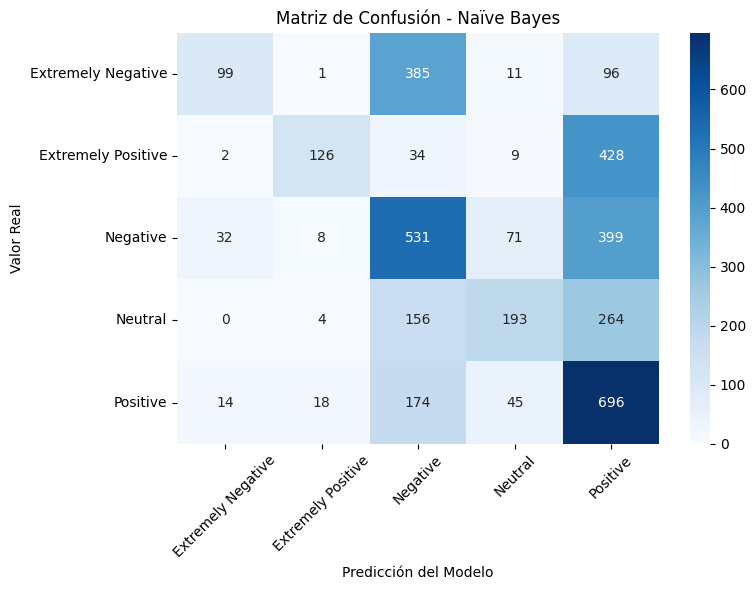

In [43]:
# ==========================================
# EVALUACIÓN 1: Naïve Bayes Multinomial
# ==========================================

# 1. Matriz de Resultados (Reporte de Clasificación)
print("-" * 50)
print("MATRIZ DE RESULTADOS: NAÏVE BAYES")
print("-" * 50)
print(classification_report(y_test, nb_pred_test, target_names=label_encoder.classes_))

# 2. Matriz de Confusión Visual
cm_nb = confusion_matrix(y_test, nb_pred_test)
plt.figure(figsize=(8, 6))
# Usamos el mapa de color 'Blues' para este modelo
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Naïve Bayes')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En esa sección se ejecuta la evaluación formal del desempeño para el modelo de Naïve Bayes Multinomial, usando métricas estadísticas y visuales para validar la efectividad del modelo. Primero, se genera un reporte de clasificación que especifica la precisión, el recall y el F1-score para cada una de las cinco categorías de sentimiento, permitiendo identificar en qué clases el modelo presenta mayores dificultades para predecir los resultados. Luego, se hace una matriz de confusión visual, que permite la detección de sesgos y errores específicos al enseñar gráficamente cuántas veces el modelo acertó y hacia qué categorías se desviaron las predicciones incorrectas, sirviendo así como la base comparativa inicial para el resto de las evaluaciones.

--------------------------------------------------
MATRIZ DE RESULTADOS: SVM (LinearSVC)
--------------------------------------------------
                    precision    recall  f1-score   support

Extremely Negative       0.56      0.54      0.55       592
Extremely Positive       0.62      0.63      0.62       599
          Negative       0.50      0.44      0.46      1041
           Neutral       0.59      0.69      0.64       617
          Positive       0.48      0.51      0.50       947

          accuracy                           0.54      3796
         macro avg       0.55      0.56      0.55      3796
      weighted avg       0.54      0.54      0.54      3796



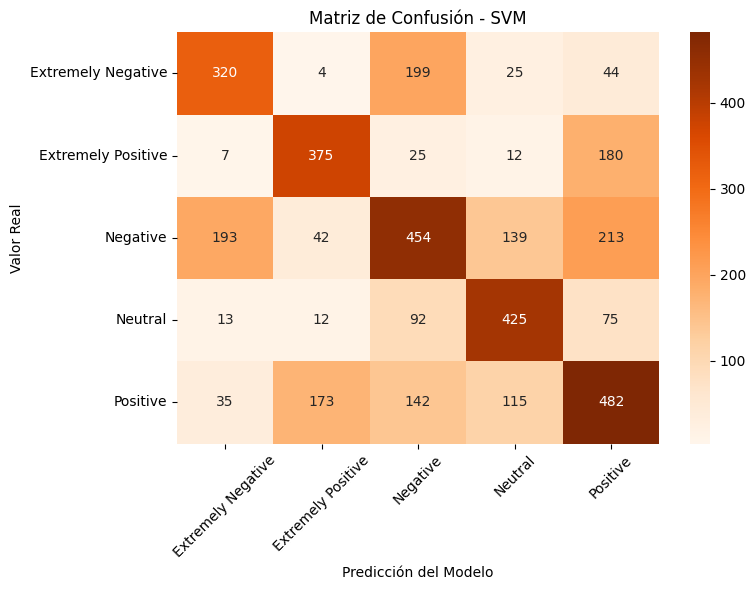

In [45]:
# ==========================================
# EVALUACIÓN 2: Support Vector Machine (SVM)
# ==========================================

# 1. Matriz de Resultados (Reporte de Clasificación)
print("-" * 50)
print("MATRIZ DE RESULTADOS: SVM (LinearSVC)")
print("-" * 50)
print(classification_report(y_test, svm_pred_test, target_names=label_encoder.classes_))

# 2. Matriz de Confusión Visual
cm_svm = confusion_matrix(y_test, svm_pred_test)
plt.figure(figsize=(8, 6))
# Usamos el mapa de color 'Oranges' para diferenciarlo visualmente
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - SVM')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Acá, el código se encarga de hacer la evaluación del modelo Support Vector Machine (SVM), permitiendo así un análisis detallado de su clasificación con respecto al conjunto de prueba. Primeramente, se despliega un reporte de métricas que incluye precisión, recall y el puntaje F1 por cada etiqueta, lo que ayuda a cuantificar e identificar la mejora en la distinción de sentimientos complejos. En la segunda parte, se genera una matriz de confusión personalizada con un mapa de calor, creada para identificar visualmente si el modelo logra una mejor separación entre clases adyacentes y para verificar la robustez de los hiperplanos de decisión calculados durante el entrenamiento.

--------------------------------------------------
MATRIZ DE RESULTADOS: RED NEURONAL PROFUNDA
--------------------------------------------------
                    precision    recall  f1-score   support

Extremely Negative       0.68      0.55      0.60       592
Extremely Positive       0.75      0.61      0.67       599
          Negative       0.55      0.61      0.58      1041
           Neutral       0.69      0.66      0.67       617
          Positive       0.55      0.64      0.59       947

          accuracy                           0.61      3796
         macro avg       0.64      0.61      0.62      3796
      weighted avg       0.62      0.61      0.61      3796



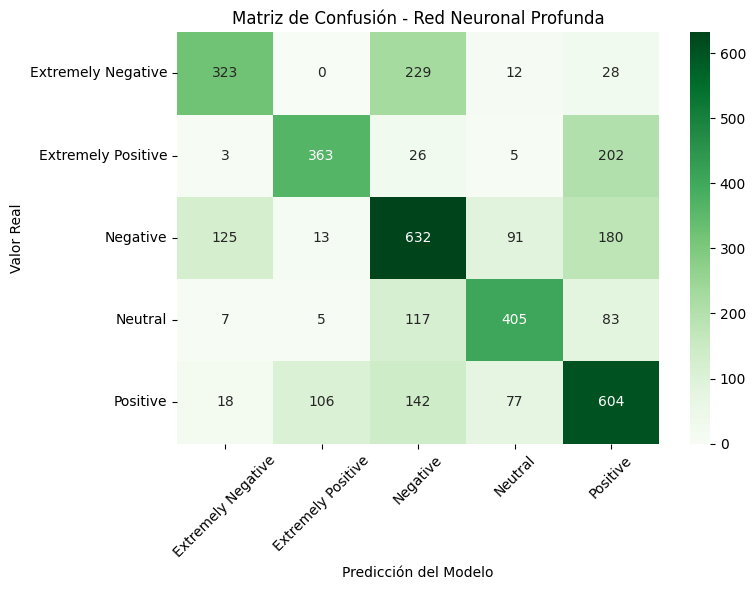

In [ ]:
# ==========================================
# EVALUACIÓN 3: Red Neuronal Profunda (Keras)
# ==========================================

# 1. Matriz de Resultados
print("-" * 50)
print("MATRIZ DE RESULTADOS: RED NEURONAL PROFUNDA")
print("-" * 50)
print(classification_report(y_test, dl_pred_test, target_names=label_encoder.classes_))

# 2. Matriz de Confusión Visual
cm_dl = confusion_matrix(y_test, dl_pred_test)
plt.figure(figsize=(8, 6))
# Usamos el mapa de color 'Greens' para el modelo de Deep Learning
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Red Neuronal Profunda')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En esta parte, se ejecuta la fase de diagnóstico para el modelo de Red Neuronal Profunda, permitiendo así contrastar su desempeño basado en aprendizaje profundo frente a los métodos estadísticos y lineales previos. Primero, se genera un reporte de clasificación detallado, el cual enseña las métricas de precisión, recall y F1-score para cada nivel de sentimiento, dando evidencia de la capacidad de la red para entender las relaciones no lineales en los datos. Por último, se crea una matriz de confusión visual, la cual permite dejar ver la densidad de aciertos en la diagonal principal y examinar cómo la arquitectura multicapa logra minimizar la confusión entre categorías extremas de sentimiento.

# Análisis del resultado

### Análisis

**Análisis de Naïve Bayes Multinomial:** Este modelo presentó el rendimiento más bajo del pipeline con un 43% de accuracy. A pesar de que fue preciso al identificar tweets "Extremely Positive", su recall fue sumamente bajo en las categorías extremas. Al asumir independencia entre palabras, el algoritmo resultó ser demasiado conservador y tuvo dificultades para captar matices emocionales complejos, tendiendo a agrupar erróneamente los textos en categorías regulares e ignorando casi por completo la clase "Neutral".

**Análisis de SVM - LinearSVC:** El presente modelo dio una mejora significativa, alcanzando así un 54% de accuracy y un F1-score ponderado de 0.54. Logró un mejor equilibrio general, destacando especialmente en la clasificación de la categoría "Neutral". A pesar de que este modelo es una herramienta robusta y excelente para encontrar hiperplanos de separación en matrices TF-IDF de alta dimensionalidad, aún presentó ciertas dificultades para distinguir entre clases adyacentes.

**Análisis de Red Neuronal Profunda:** Este modelo fue el ganador definitivo, teniendo un 61% de accuracy y F1-score de 0.61. Adicional, reveló mejoras en todas las métricas y generó la matriz de confusión más fuerte, identificando así correctamente las clases "Extremely Positive" y "Neutral". Su arquitectura multicapa demostró una capacidad superior para capturar relaciones no lineales complejas. A pesar de que todavía confunde categorías adyacentes, evita errores graves, superando con creces las limitaciones de los modelos lineales previos.

### Conclusiones

- Se confirmó con efectivamente la el objetivo principal del proyecto. La transición de modelos estadísticos tradicionales hacia arquitecturas de deep learning logró generar un impacto predictivo positivo. La Red Neuronal que se implementó tuvo una precisión con un 18% más alto que el modelo base (Naïve Bayes), confirmando así la superioridad del Deep Learning para este proyecto.

- Asimismo, tratar de medir el sentimiento en 5 niveles tan detallados genera confusiones naturales al intentar distinguir entre emociones muy parecidas, incluso para analistas humanos. Desde una perspectiva de inteligencia de negocio, se recomienda consolidar el análisis a 3 categorías principales (Positivo, Negativo, Neutral). Esta categorización reduciría la ambigüedad en los modelos, disminuiría los falsos positivos entre extremos y aumentaría la confiabilidad del sistema para la toma de decisiones.

- Si bien el modelo de Deep Learning actual obtuvo el mejor rendimiento (61%), su límite técnico está condicionado por la vectorización TF-IDF, la cual omite el orden temporal y el contexto de las palabras. El verdadero salto cualitativo se ejecutará en la siguiente fase analítica mediante la integración de arquitecturas Transformer. El uso de Embeddings contextuales permitiría al algoritmo comprender la semántica completa de las oraciones, capturando así el sarcasmo y las sutilezas lingüísticas para maximizar el valor del análisis de percepción ciudadana.